# 卸料任务时间与能耗预测

本 Notebook 使用同一份数据和同一次训练集/测试集划分，比较三类模型：

1. **Baseline 1：里程比例模型**
2. **Baseline 2：普通线性回归**
3. **XGBoost：先在训练集上进行网格搜索，再使用最优模型预测测试集**

> XGBoost 不再额外训练一组手动默认参数模型，避免与网格搜索模型重复。

## 1. 导入依赖

**本单元功能**

- 导入数据处理、建模、评估、绘图和模型保存所需的库；
- 设置中文字体和表格显示选项。

首次运行前请确保已安装：

```bash
pip install pandas numpy matplotlib scikit-learn xgboost joblib
```

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_validate,
    train_test_split,
)
from xgboost import XGBRegressor


# 绘图显示设置
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans",
]

# 表格显示设置
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("依赖导入完成。")

依赖导入完成。


## 2. 配置数据路径、特征和训练参数

**本单元功能**

- 指定特征 JSON 文件目录和结果保存目录；
- 定义模型输入特征和两个预测目标；
- 设置训练集/测试集比例、随机种子和网格搜索折数。

通常只需要修改 `DATA_DIR` 和 `OUTPUT_DIR`。

In [2]:
# =========================
# 1. 文件路径
# =========================

# 特征 JSON 所在目录
DATA_DIR = Path(r"C:\Users\14993\PycharmProjects\BoLei-DataMining\data\FeatureData")

# 模型和结果保存目录
OUTPUT_DIR = Path(r"C:\Users\14993\PycharmProjects\BoLei-DataMining\target\ModelResults")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================
# 2. 输入特征与预测目标
# =========================

FEATURE_COLS = [
    "departure_hour_sin",
    "departure_hour_cos",
    "total_distance_odometer_m",
    "total_altitude_change_m",
    "pitch_mean",
    "pitch_std",
    "speed_mean",
    "speed_std",
    "slope_sin_mean",
    "slope_sin_std",
    "straight_line_distance_m"
]

TIME_TARGET = "task_duration_s"
ENERGY_TARGET = "total_energy_soc_delta_pct"


# =========================
# 3. 数据划分与网格搜索设置
# =========================

TEST_SIZE = 0.2
RANDOM_STATE = 42
GRID_SEARCH_CV_FOLDS = 5

# GridSearchCV 并行进程数：
# -1 表示使用全部可用 CPU；如内存不足可改为 1。
GRID_SEARCH_N_JOBS = -1

print("数据目录：", DATA_DIR)
print("结果目录：", OUTPUT_DIR)
print(f"测试集比例：{TEST_SIZE:.0%}")
print(f"网格搜索交叉验证折数：{GRID_SEARCH_CV_FOLDS}")

数据目录： C:\Users\14993\PycharmProjects\BoLei-DataMining\data\FeatureData
结果目录： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\ModelResults
测试集比例：20%
网格搜索交叉验证折数：5


## 3. 读取并清洗全部 JSON 数据

**本单元功能**

- 递归读取 `DATA_DIR` 下的所有 JSON 文件；
- 兼容 `{"tasks": [...]}` 和直接任务列表 `[...]` 两种结构；
- 检查必要字段；
- 将特征和标签转换为数值；
- 删除缺失值、非正行程时间和负里程记录；
- 合并为一个 DataFrame。

**输出**

- `df`：清洗后的完整任务数据。

In [3]:
def load_dataset(data_dir):
    json_files = sorted(data_dir.rglob("*.json"))

    if not json_files:
        raise FileNotFoundError(f"没有找到 JSON 文件：{data_dir}")

    required_cols = FEATURE_COLS + [TIME_TARGET, ENERGY_TARGET]
    all_data = []
    skipped_files = []

    for json_file in json_files:
        try:
            with json_file.open("r", encoding="utf-8") as file:
                data = json.load(file)

            if isinstance(data, dict) and isinstance(data.get("tasks"), list):
                tasks = data["tasks"]
            elif isinstance(data, list):
                tasks = data
            else:
                skipped_files.append((json_file.name, "没有任务列表"))
                continue

            file_df = pd.DataFrame(tasks)

            missing_cols = [
                col for col in required_cols
                if col not in file_df.columns
            ]

            if missing_cols:
                skipped_files.append(
                    (json_file.name, f"缺少字段：{missing_cols}")
                )
                continue

            if "task_id" not in file_df.columns:
                file_df["task_id"] = pd.NA

            if "task_index" not in file_df.columns:
                file_df["task_index"] = pd.NA

            file_df["source_file"] = str(
                json_file.relative_to(data_dir)
            )

            keep_cols = (
                required_cols
                + ["task_id", "task_index", "source_file"]
            )
            all_data.append(file_df[keep_cols].copy())

        except Exception as error:
            skipped_files.append((json_file.name, str(error)))

    if not all_data:
        raise ValueError("没有成功读取任何可用数据。")

    dataset = pd.concat(all_data, ignore_index=True)

    for col in required_cols:
        dataset[col] = pd.to_numeric(dataset[col], errors="coerce")

    original_count = len(dataset)

    dataset = dataset.dropna(subset=required_cols)
    dataset = dataset[
        (dataset["total_distance_odometer_m"] >= 0)
        & (dataset[TIME_TARGET] > 0)
    ].reset_index(drop=True)

    print(f"发现 JSON 文件数：{len(json_files)}")
    print(f"成功读取文件数：{len(all_data)}")
    print(f"原始任务数：{original_count}")
    print(f"有效任务数：{len(dataset)}")
    print(f"删除无效任务数：{original_count - len(dataset)}")

    if skipped_files:
        print(f"\n跳过文件数：{len(skipped_files)}")
        for file_name, reason in skipped_files:
            print(f"- {file_name}: {reason}")

    return dataset


df = load_dataset(DATA_DIR)

发现 JSON 文件数：20
成功读取文件数：20
原始任务数：3210
有效任务数：3210
删除无效任务数：0


## 4. 查看数据概况

**本单元功能**

- 查看合并后的数据规模和文件数量；
- 预览前几条任务；
- 检查各特征和标签的统计分布。

此单元只用于数据检查，不参与模型训练。

In [4]:
print("数据形状：", df.shape)
print("数据文件数：", df["source_file"].nunique())

display(df.head())

summary_cols = FEATURE_COLS + [TIME_TARGET, ENERGY_TARGET]
display(df[summary_cols].describe().T.round(4))

数据形状： (3210, 16)
数据文件数： 20


,departure_hour_sin,departure_hour_cos,total_distance_odometer_m,total_altitude_change_m,pitch_mean,pitch_std,speed_mean,speed_std,slope_sin_mean,slope_sin_std,straight_line_distance_m,task_duration_s,total_energy_soc_delta_pct,task_id,task_index,source_file
0,-0.456174,-0.889890,3500.0,144.5831,-1.928053,2.509720,3.297326,1.592501,0.041162,0.032420,2349.129850,1078.880390,14.8,8061955916906753,1,TLE00860CR1450020卸料任务_特征和标签.json
1,-0.914676,0.404187,4500.0,132.5124,-1.727225,2.499827,4.281888,2.113034,0.029442,0.034638,2931.200681,1078.446503,13.6,8062296833835265,2,TLE00860CR1450020卸料任务_特征和标签.json
2,-0.695656,0.718375,4125.0,172.0542,-2.281552,2.496671,3.504632,1.329558,0.041521,0.029248,2117.307809,1218.586187,16.0,8062383657042177,3,TLE00860CR1450020卸料任务_特征和标签.json
3,-0.521993,0.852950,3500.0,144.3345,-1.711009,2.469314,3.076494,1.659597,0.041108,0.028335,2320.774277,1193.786143,12.8,8062433255342337,4,TLE00860CR1450020卸料任务_特征和标签.json
4,-0.110991,0.993821,5125.0,161.8966,-2.033794,2.352843,4.059008,2.049870,0.031554,0.034708,2648.932888,1303.056854,16.0,8062531927441665,5,TLE00860CR1450020卸料任务_特征和标签.json


,count,mean,std,min,25%,50%,75%,max
departure_hour_sin,3210.0,0.0160,0.6976,-1.0000,-0.6525,0.0243,0.6966,1.0000
departure_hour_cos,3210.0,0.0622,0.7138,-1.0000,-0.6816,0.1170,0.7845,1.0000
total_distance_odometer_m,3210.0,3894.2757,652.4424,2500.0000,3375.0000,3875.0000,4375.0000,6125.0000
total_altitude_change_m,3210.0,147.0768,24.6324,101.2538,123.3096,146.1561,173.5772,192.8145
pitch_mean,3210.0,-1.9226,0.8203,-4.4335,-2.5663,-1.8409,-1.3656,0.4365
pitch_std,3210.0,2.4155,0.1696,1.7874,2.2971,2.4035,2.5270,3.6636
speed_mean,3210.0,3.4036,0.2928,1.6608,3.2678,3.4211,3.5527,4.2819
speed_std,3210.0,1.5800,0.2456,0.6206,1.3972,1.5347,1.7016,2.6924
slope_sin_mean,3210.0,0.0380,0.0049,0.0247,0.0346,0.0384,0.0413,0.0513
slope_sin_std,3210.0,0.0316,0.0030,0.0231,0.0294,0.0313,0.0335,0.0441


## 5. 统一划分训练集和测试集

**本单元功能**

- 按相同索引划分训练集和测试集；
- 为时间预测和能耗预测准备相同的输入特征；
- 保证所有模型在同一批测试样本上比较。

**输出**

- `X_train`、`X_test`
- `y_time_train`、`y_time_test`
- `y_energy_train`、`y_energy_test`

In [5]:
train_index, test_index = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_df = df.loc[train_index].reset_index(drop=True)
test_df = df.loc[test_index].reset_index(drop=True)

X_train = train_df[FEATURE_COLS]
X_test = test_df[FEATURE_COLS]

y_time_train = train_df[TIME_TARGET]
y_time_test = test_df[TIME_TARGET]

y_energy_train = train_df[ENERGY_TARGET]
y_energy_test = test_df[ENERGY_TARGET]

print(f"训练集样本数：{len(train_df)}")
print(f"测试集样本数：{len(test_df)}")

训练集样本数：2568
测试集样本数：642


## 6. 定义评估和绘图函数

**本单元功能**

- `get_metrics`：计算 MAE、RMSE 和 R²；
- `plot_actual_vs_predicted`：绘制真实值与预测值散点图；
- `plot_residuals`：绘制预测残差图。

这些函数会被后续所有模型重复调用。

In [6]:
def get_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


def plot_actual_vs_predicted(y_true, y_pred, title, unit):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, s=45, alpha=0.75)
    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        linewidth=1.8,
        label="理想预测线",
    )
    plt.xlabel(f"真实值（{unit}）")
    plt.ylabel(f"预测值（{unit}）")
    plt.title(title, fontsize=14, pad=12)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred, title, unit):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    residuals = y_pred - y_true

    plt.figure(figsize=(7, 5))
    plt.scatter(y_pred, residuals, s=45, alpha=0.75)
    plt.axhline(0, linestyle="--", linewidth=1.8)
    plt.xlabel(f"预测值（{unit}）")
    plt.ylabel(f"残差（{unit}）")
    plt.title(title, fontsize=14, pad=12)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

# 7. Baseline 1：里程比例模型

假设任务时间和能耗分别与行驶里程成正比：

\[
\hat{t}=k_t d
\]

\[
\hat{e}=k_e d
\]

## 7.1 拟合比例系数

**本单元功能**

- 只使用训练集估计时间比例系数和能耗比例系数；
- 不使用测试集信息；
- 输出每米、每公里对应的时间和能耗。

In [7]:
distance_train = train_df["total_distance_odometer_m"].to_numpy()
time_train = y_time_train.to_numpy()
energy_train = y_energy_train.to_numpy()

denominator = np.sum(distance_train ** 2)

if denominator == 0:
    raise ValueError("训练集里程全部为 0，无法拟合里程比例模型。")

baseline1_time_k = (
    np.sum(distance_train * time_train)
    / denominator
)

baseline1_energy_k = (
    np.sum(distance_train * energy_train)
    / denominator
)

print(f"时间比例系数：{baseline1_time_k:.8f} 秒/米")
print(f"每公里预测时间：{baseline1_time_k * 1000:.4f} 秒/公里")

if baseline1_time_k > 0:
    constant_speed = 3.6 / baseline1_time_k
    print(f"对应的等效恒定速度：{constant_speed:.4f} km/h")

print(
    f"能耗比例系数："
    f"{baseline1_energy_k:.10f} SOC 百分点/米"
)
print(
    f"每公里预测能耗："
    f"{baseline1_energy_k * 1000:.6f} SOC 百分点/公里"
)

时间比例系数：0.30766764 秒/米
每公里预测时间：307.6676 秒/公里
对应的等效恒定速度：11.7009 km/h
能耗比例系数：0.0037272485 SOC 百分点/米
每公里预测能耗：3.727248 SOC 百分点/公里


## 7.2 预测测试集并计算指标

**本单元功能**

- 使用训练集得到的两个比例系数预测测试集；
- 计算时间和能耗的 MAE、RMSE、R²；
- 生成后续保存模型所需的比例模型字典。

In [8]:
baseline1_time_pred = (
    baseline1_time_k
    * test_df["total_distance_odometer_m"].to_numpy()
)

baseline1_energy_pred = (
    baseline1_energy_k
    * test_df["total_distance_odometer_m"].to_numpy()
)

baseline1_time_metrics = get_metrics(
    y_time_test,
    baseline1_time_pred,
)

baseline1_energy_metrics = get_metrics(
    y_energy_test,
    baseline1_energy_pred,
)

baseline1_model_data = {
    "model_name": "distance_proportional_time_and_energy_baseline",
    "distance_feature": "total_distance_odometer_m",
    "time": {
        "formula": (
            "predicted_task_duration_s = "
            "time_coefficient_s_per_m * "
            "total_distance_odometer_m"
        ),
        "time_coefficient_s_per_m": float(baseline1_time_k),
        "time_coefficient_s_per_km": float(
            baseline1_time_k * 1000
        ),
    },
    "energy": {
        "formula": (
            "predicted_energy_soc_pct = "
            "energy_coefficient_soc_pct_per_m * "
            "total_distance_odometer_m"
        ),
        "energy_coefficient_soc_pct_per_m": float(
            baseline1_energy_k
        ),
        "energy_coefficient_soc_pct_per_km": float(
            baseline1_energy_k * 1000
        ),
    },
    "train_sample_count": len(train_df),
}

print("任务时间测试集指标：")
display(pd.DataFrame(
    [baseline1_time_metrics],
    index=["里程比例 Baseline"],
).round(4))

print("行程能耗测试集指标：")
display(pd.DataFrame(
    [baseline1_energy_metrics],
    index=["里程比例 Baseline"],
).round(4))

任务时间测试集指标：


,MAE,RMSE,R2
里程比例 Baseline,98.5729,137.0994,0.5025


行程能耗测试集指标：


,MAE,RMSE,R2
里程比例 Baseline,1.4137,1.7477,0.5392


## 7.3 查看逐条预测和误差图

**本单元功能**

- 展示测试集前 10 条预测；
- 计算预测值减真实值的残差；
- 绘制时间和能耗的拟合图及残差图。

,task_id,source_file,total_distance_odometer_m,task_duration_s,total_energy_soc_delta_pct,pred_task_duration_s,time_residual_s,pred_energy_soc_pct,energy_residual_soc_pct
0,8065986810708225,TLE00860HR1450010卸料任务_特征和标签.json,3375.0,1002.1024,14.4,1038.3783,36.2759,12.5795,-1.8205
1,8066176061194497,TLE00900CR1450050卸料任务_特征和标签.json,4375.0,1409.4458,18.4,1346.0459,-63.3998,16.3067,-2.0933
2,8094951438336257,TLE00900VR1450048最终有效卸货记录615-707_cleaned_特征和标签...,3250.0,1025.8506,13.2,999.9198,-25.9308,12.1136,-1.0864
3,8062584127078657,TLE00900JR1450046卸料任务_特征和标签.json,3250.0,1140.1710,13.6,999.9198,-140.2511,12.1136,-1.4864
4,8099212179472641,TLE00860VR1450018最终有效卸货记录615-707_cleaned_特征和标签...,3500.0,1194.9745,12.0,1076.8368,-118.1377,13.0454,1.0454
5,8066256954654977,TLE00900AR1450052卸料任务_特征和标签.json,5250.0,1426.3102,18.0,1615.2551,188.9449,19.5681,1.5681
6,8087961773113601,TLE00860HR1450010最终有效卸货记录615-707_cleaned_特征和标签...,4125.0,1113.0407,12.8,1269.1290,156.0883,15.3749,2.5749
7,8101046186524929,TLE00900CR1450050最终有效卸货记录615-707_cleaned_特征和标签...,3125.0,1303.7853,12.8,961.4614,-342.3239,11.6477,-1.1523
8,8065180703752449,TLE00860HR1450010卸料任务_特征和标签.json,3875.0,1203.6099,16.8,1192.2121,-11.3978,14.4431,-2.3569
9,8085294128709889,TLE00900AR1450049最终有效卸货记录615-707_cleaned_特征和标签...,4375.0,1291.9774,17.6,1346.0459,54.0685,16.3067,-1.2933


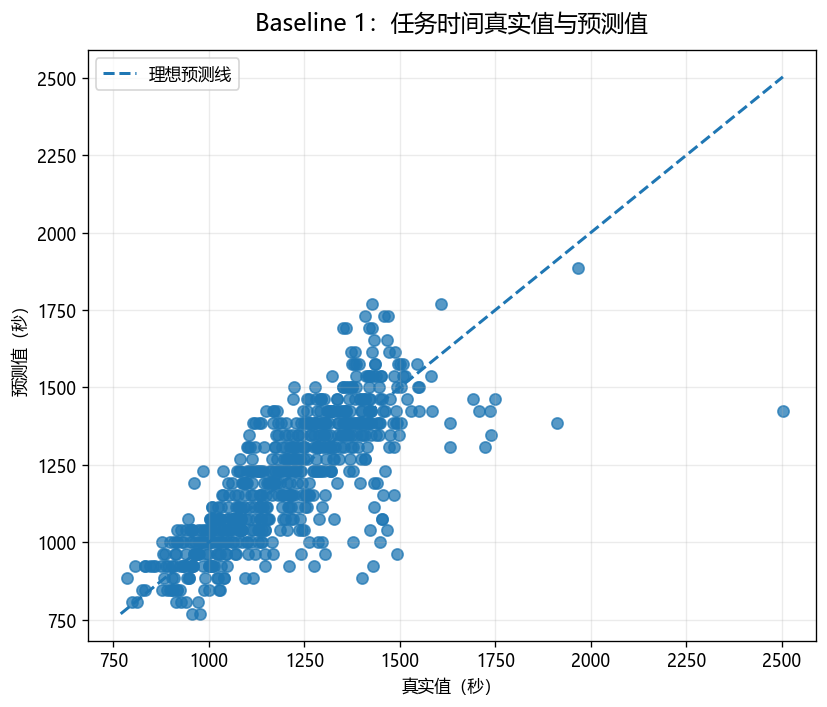

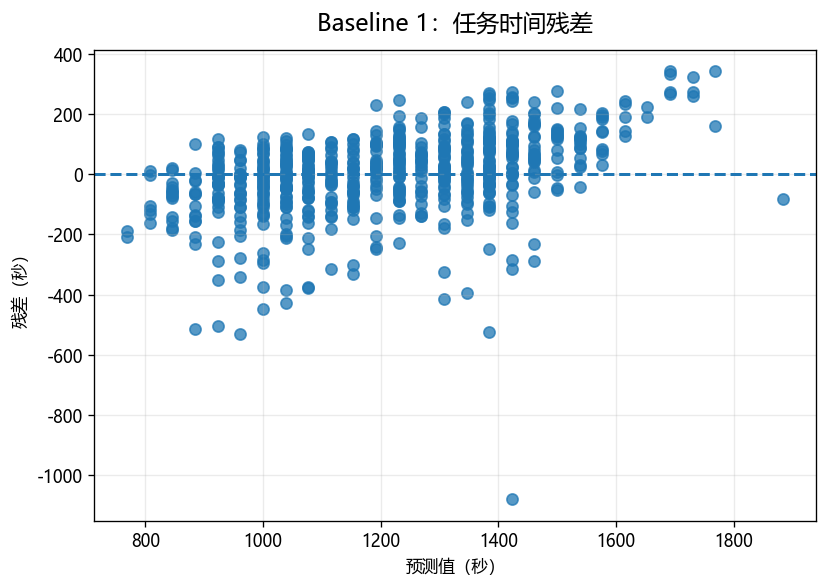

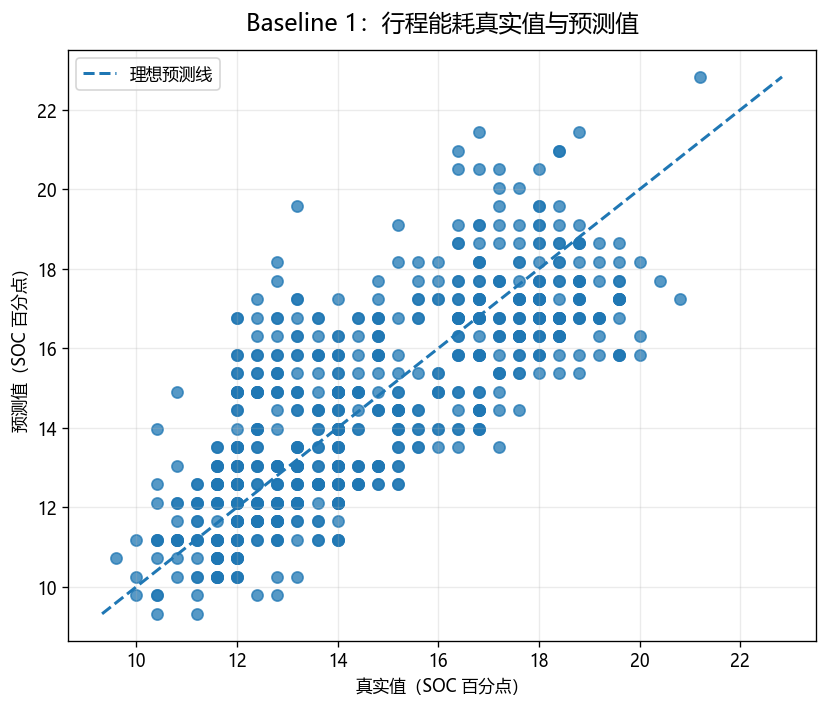

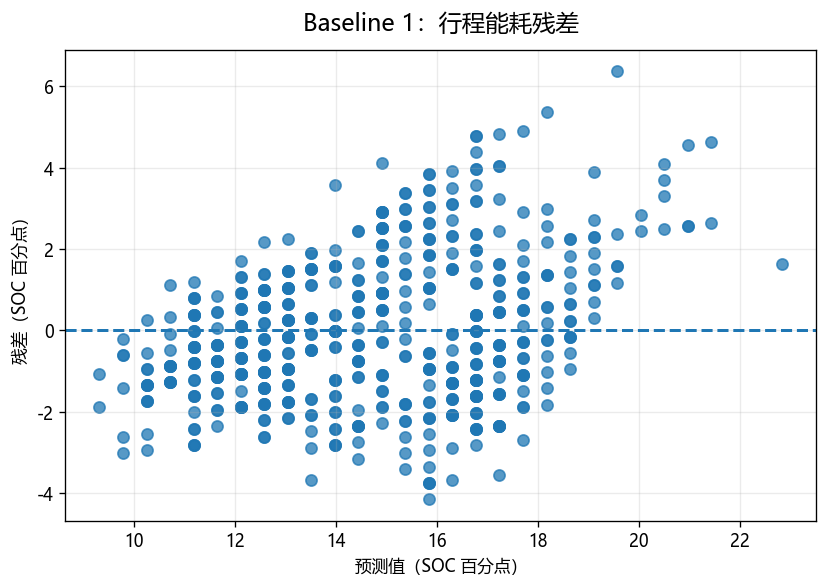

In [9]:
baseline1_preview = test_df[
    [
        "task_id",
        "source_file",
        "total_distance_odometer_m",
        TIME_TARGET,
        ENERGY_TARGET,
    ]
].copy()

baseline1_preview["pred_task_duration_s"] = baseline1_time_pred
baseline1_preview["time_residual_s"] = (
    baseline1_preview["pred_task_duration_s"]
    - baseline1_preview[TIME_TARGET]
)

baseline1_preview["pred_energy_soc_pct"] = baseline1_energy_pred
baseline1_preview["energy_residual_soc_pct"] = (
    baseline1_preview["pred_energy_soc_pct"]
    - baseline1_preview[ENERGY_TARGET]
)

display(baseline1_preview.head(10).round(4))

plot_actual_vs_predicted(
    y_time_test,
    baseline1_time_pred,
    "Baseline 1：任务时间真实值与预测值",
    "秒",
)
plot_residuals(
    y_time_test,
    baseline1_time_pred,
    "Baseline 1：任务时间残差",
    "秒",
)

plot_actual_vs_predicted(
    y_energy_test,
    baseline1_energy_pred,
    "Baseline 1：行程能耗真实值与预测值",
    "SOC 百分点",
)
plot_residuals(
    y_energy_test,
    baseline1_energy_pred,
    "Baseline 1：行程能耗残差",
    "SOC 百分点",
)

# 8. Baseline 2：普通线性回归

## 8.1 训练并评估时间模型和能耗模型

**本单元功能**

- 使用全部特征分别训练时间线性回归和能耗线性回归；
- 在测试集上预测；
- 计算两个模型的 MAE、RMSE 和 R²。

In [10]:
# 时间线性回归
linear_time_model = LinearRegression()
linear_time_model.fit(X_train, y_time_train)
linear_time_pred = linear_time_model.predict(X_test)
linear_time_metrics = get_metrics(
    y_time_test,
    linear_time_pred,
)

# 能耗线性回归
linear_energy_model = LinearRegression()
linear_energy_model.fit(X_train, y_energy_train)
linear_energy_pred = linear_energy_model.predict(X_test)
linear_energy_metrics = get_metrics(
    y_energy_test,
    linear_energy_pred,
)

print("任务时间线性回归：")
display(pd.DataFrame(
    [linear_time_metrics],
    index=["线性回归"],
).round(4))

print("能耗线性回归：")
display(pd.DataFrame(
    [linear_energy_metrics],
    index=["线性回归"],
).round(4))

任务时间线性回归：


,MAE,RMSE,R2
线性回归,32.1469,45.1877,0.946


能耗线性回归：


,MAE,RMSE,R2
线性回归,0.6132,0.8012,0.9032


## 8.2 查看线性回归系数

**本单元功能**

- 输出时间模型和能耗模型的截距；
- 按系数绝对值排序展示各特征系数。

注意：不同特征量纲不同，原始系数大小不能直接等同于特征重要性。

In [11]:
linear_time_coef = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": linear_time_model.coef_,
})

linear_energy_coef = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": linear_energy_model.coef_,
})

print(f"任务时间模型截距：{linear_time_model.intercept_:.6f}")
display(
    linear_time_coef
    .sort_values("coefficient", key=abs, ascending=False)
    .round(6)
)

print(f"能耗模型截距：{linear_energy_model.intercept_:.6f}")
display(
    linear_energy_coef
    .sort_values("coefficient", key=abs, ascending=False)
    .round(6)
)

任务时间模型截距：1109.480644


,feature,coefficient
9,slope_sin_std,6591.773599
6,speed_mean,-432.661809
8,slope_sin_mean,-193.497614
7,speed_std,70.010944
5,pitch_std,-8.109228
4,pitch_mean,5.343619
0,departure_hour_sin,-2.856174
3,total_altitude_change_m,1.420790
1,departure_hour_cos,-0.263702
2,total_distance_odometer_m,0.242490


能耗模型截距：-1.534950


,feature,coefficient
8,slope_sin_mean,-38.675805
9,slope_sin_std,31.149198
6,speed_mean,-0.473447
5,pitch_std,0.472288
7,speed_std,0.399142
4,pitch_mean,-0.103010
3,total_altitude_change_m,0.089627
1,departure_hour_cos,0.067811
0,departure_hour_sin,-0.058084
2,total_distance_odometer_m,0.000620


## 8.3 绘制线性回归预测结果

**本单元功能**

- 绘制任务时间真实值—预测值图和残差图；
- 绘制能耗真实值—预测值图和残差图。

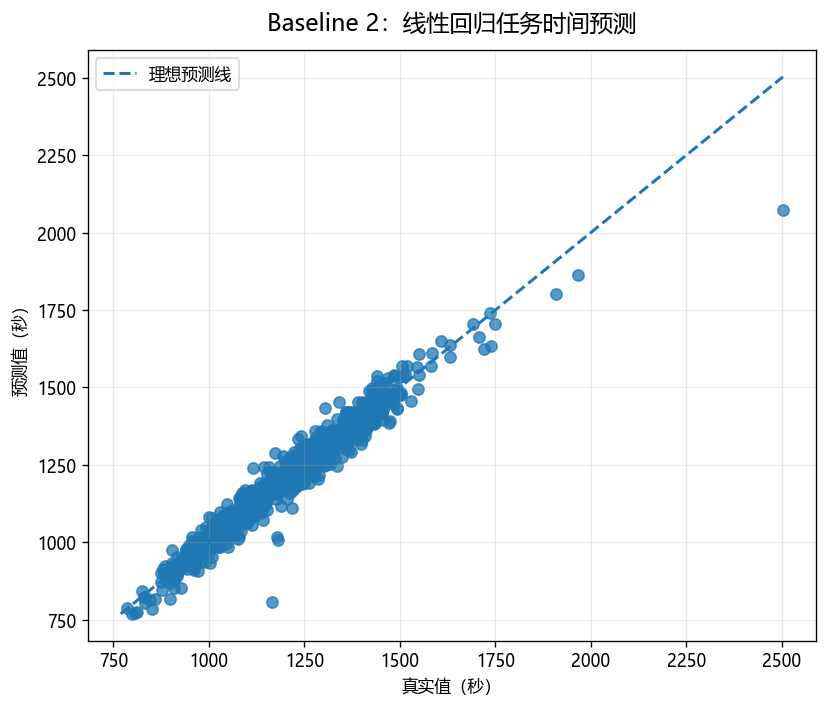

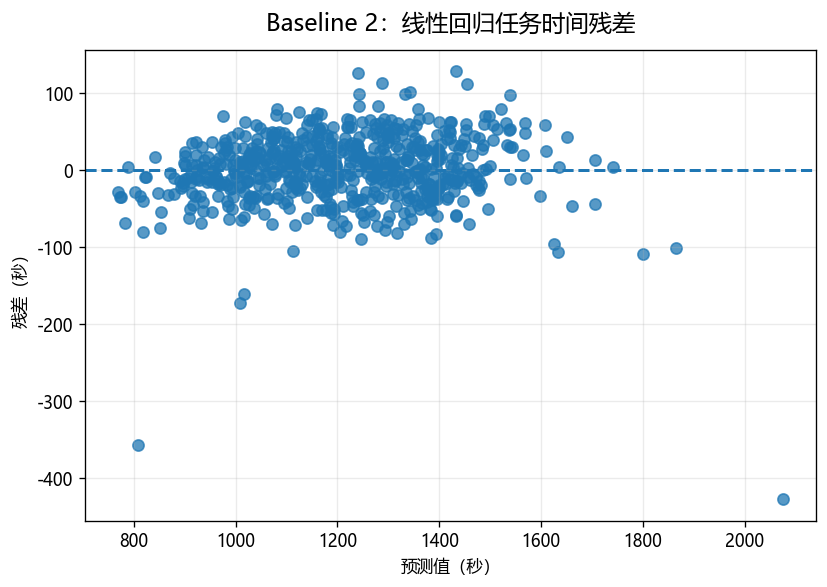

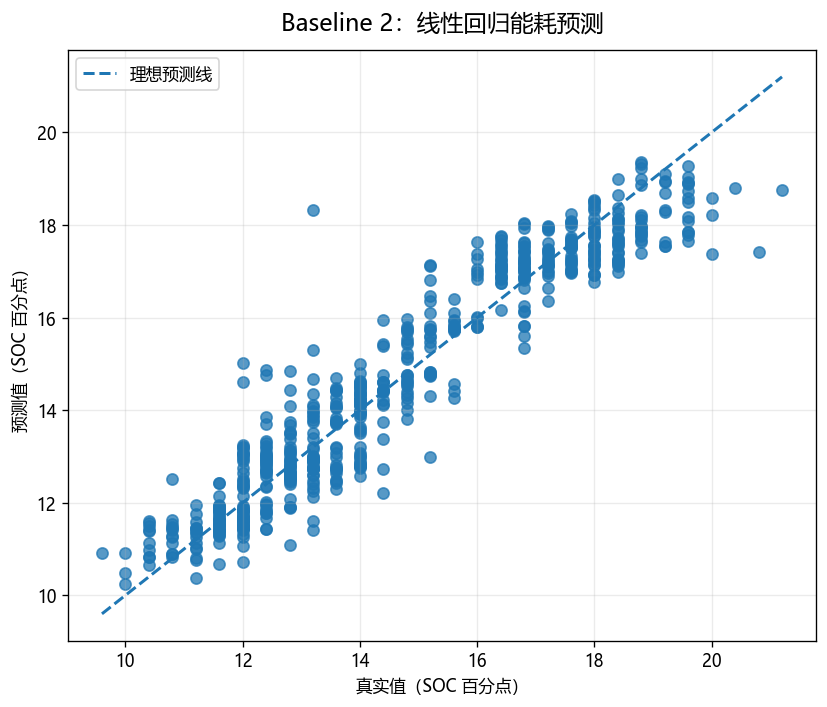

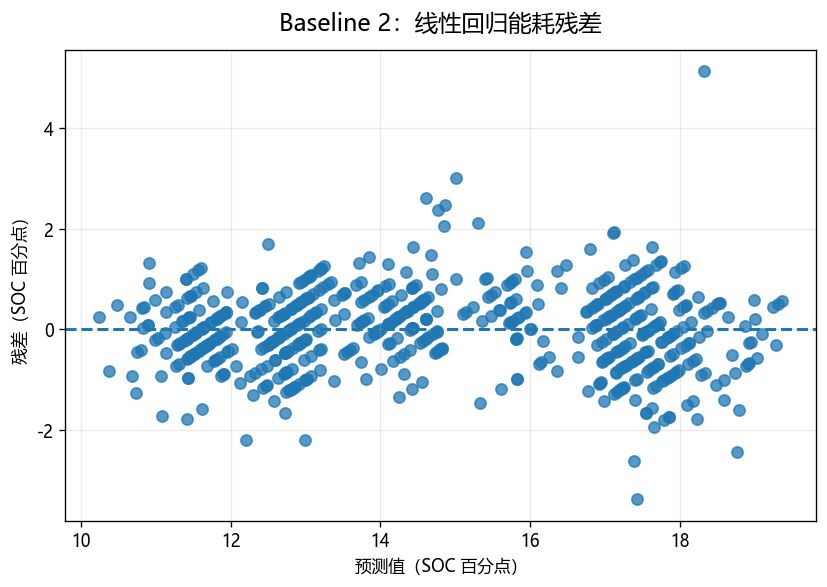

In [12]:
plot_actual_vs_predicted(
    y_time_test,
    linear_time_pred,
    "Baseline 2：线性回归任务时间预测",
    "秒",
)
plot_residuals(
    y_time_test,
    linear_time_pred,
    "Baseline 2：线性回归任务时间残差",
    "秒",
)

plot_actual_vs_predicted(
    y_energy_test,
    linear_energy_pred,
    "Baseline 2：线性回归能耗预测",
    "SOC 百分点",
)
plot_residuals(
    y_energy_test,
    linear_energy_pred,
    "Baseline 2：线性回归能耗残差",
    "SOC 百分点",
)

# 9. XGBoost：网格搜索后训练最优模型

流程如下：

1. 定义待搜索参数；
2. 只在训练集上进行交叉验证；
3. 时间目标和能耗目标分别搜索；
4. `GridSearchCV(refit=True)` 自动使用最佳参数在完整训练集上重新拟合；
5. 最优模型预测测试集。

不再训练额外的“默认参数 XGBoost”。

## 9.1 定义参数网格和交叉验证策略

**本单元功能**

- 定义 XGBoost 参数候选值；
- 计算参数组合数量；
- 创建仅用于训练集网格搜索的 K 折交叉验证器。

树数量、树深、学习率和采样比例由网格搜索选择；正则化相关参数沿用原方案作为固定设置。

In [13]:
xgb_param_grid = {
    "n_estimators": [80, 120, 160, 200, 240],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.10],
    "subsample": [0.80, 0.90, 1.00],
    "colsample_bytree": [0.80, 0.90, 1.00],
}

grid_size = int(np.prod([
    len(values)
    for values in xgb_param_grid.values()
]))

search_cv_folds = min(
    GRID_SEARCH_CV_FOLDS,
    len(X_train) // 2,
)

if search_cv_folds < 2:
    raise ValueError("训练样本太少，无法进行网格搜索。")

search_cv = KFold(
    n_splits=search_cv_folds,
    shuffle=True,
    random_state=RANDOM_STATE,
)

print(f"参数组合数：{grid_size}")
print(f"每个目标需要拟合：{grid_size * search_cv_folds} 次")
print(f"使用 {search_cv_folds} 折交叉验证。")

参数组合数：720
每个目标需要拟合：3600 次
使用 5 折交叉验证。


> 当前参数网格组合较多。若运行时间过长，可先缩小每个列表的候选值，再围绕第一轮最优参数进行第二轮细化搜索。

## 9.2 搜索任务时间模型的最优参数

**本单元功能**

- 对任务时间标签执行网格搜索；
- 使用训练集交叉验证 RMSE 选择参数；
- 自动在完整训练集上重新拟合最佳模型；
- 输出最佳参数和最佳交叉验证 RMSE。

**输出**

- `time_grid_search`
- `xgb_time_model`

In [14]:
time_grid_search = GridSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        min_child_weight=2,
        reg_alpha=0.1,
        reg_lambda=3.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=search_cv,
    n_jobs=GRID_SEARCH_N_JOBS,
    verbose=1,
    return_train_score=True,
    refit=True,
)

time_grid_search.fit(X_train, y_time_train)

# best_estimator_ 已使用最佳参数在完整训练集上重新拟合
xgb_time_model = time_grid_search.best_estimator_

print("任务时间最优参数：")
display(pd.DataFrame(
    list(time_grid_search.best_params_.items()),
    columns=["parameter", "best_value"],
))

print(
    "任务时间最优训练集 CV RMSE："
    f"{-time_grid_search.best_score_:.4f} 秒"
)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
任务时间最优参数：


,parameter,best_value
0,colsample_bytree,1.0
1,learning_rate,0.1
2,max_depth,5.0
3,n_estimators,240.0
4,subsample,0.8


任务时间最优训练集 CV RMSE：35.6500 秒


## 9.3 查看任务时间网格搜索前 10 组结果

**本单元功能**

- 将完整搜索结果转换为 DataFrame；
- 按交叉验证排名选出前 10 组；
- 展示各组合的 RMSE、波动和参数。

,组合,CV_RMSE,std_test_score,params
717,组合 1,35.6500,2.0316,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
714,组合 2,35.8371,2.1054,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
703,组合 3,36.0919,2.4248,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
718,组合 4,36.1168,3.6771,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
711,组合 5,36.1467,2.0350,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
715,组合 6,36.2957,3.6761,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
657,组合 7,36.3000,2.8782,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
704,组合 8,36.3191,2.9675,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
658,组合 9,36.4127,2.6818,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
700,组合 10,36.4360,2.3735,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."


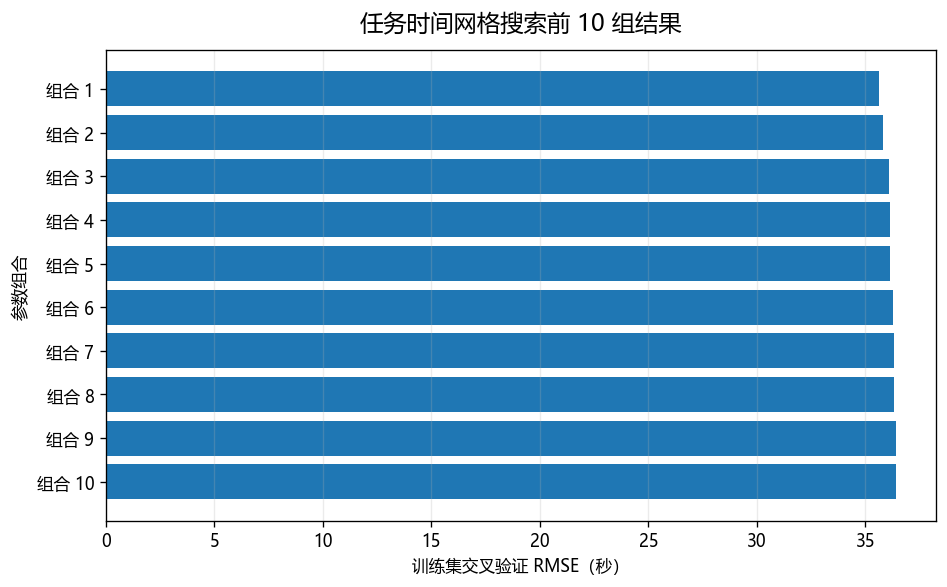

In [15]:
time_grid_results = pd.DataFrame(
    time_grid_search.cv_results_
)

time_grid_results["CV_RMSE"] = (
    -time_grid_results["mean_test_score"]
)

time_grid_top10 = (
    time_grid_results
    .sort_values("rank_test_score")
    .head(10)
    .copy()
)

time_grid_top10["组合"] = [
    f"组合 {index}"
    for index in range(1, len(time_grid_top10) + 1)
]

display(
    time_grid_top10[
        ["组合", "CV_RMSE", "std_test_score", "params"]
    ].round(4)
)

plt.figure(figsize=(8, 5))
plt.barh(
    time_grid_top10["组合"][::-1],
    time_grid_top10["CV_RMSE"][::-1],
)
plt.xlabel("训练集交叉验证 RMSE（秒）")
plt.ylabel("参数组合")
plt.title("任务时间网格搜索前 10 组结果", fontsize=14, pad=12)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 9.4 搜索能耗模型的最优参数

**本单元功能**

- 对能耗标签单独执行网格搜索；
- 不直接复用任务时间模型参数；
- 自动在完整训练集上重新拟合最佳模型；
- 输出最佳参数和最佳交叉验证 RMSE。

**输出**

- `energy_grid_search`
- `xgb_energy_model`

In [16]:
energy_grid_search = GridSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        min_child_weight=2,
        reg_alpha=0.1,
        reg_lambda=3.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=search_cv,
    n_jobs=GRID_SEARCH_N_JOBS,
    verbose=1,
    return_train_score=True,
    refit=True,
)

energy_grid_search.fit(X_train, y_energy_train)

# best_estimator_ 已使用最佳参数在完整训练集上重新拟合
xgb_energy_model = energy_grid_search.best_estimator_

print("能耗最优参数：")
display(pd.DataFrame(
    list(energy_grid_search.best_params_.items()),
    columns=["parameter", "best_value"],
))

print(
    "能耗最优训练集 CV RMSE："
    f"{-energy_grid_search.best_score_:.4f} SOC 百分点"
)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
能耗最优参数：


,parameter,best_value
0,colsample_bytree,0.90
1,learning_rate,0.03
2,max_depth,5.00
3,n_estimators,240.00
4,subsample,0.90


能耗最优训练集 CV RMSE：0.7511 SOC 百分点


## 9.5 查看能耗网格搜索前 10 组结果

**本单元功能**

- 整理能耗模型的全部搜索结果；
- 展示交叉验证表现最好的前 10 组参数；
- 绘制前 10 组 RMSE 对比图。

,组合,CV_RMSE,std_test_score,params
358,组合 1,0.7511,0.0417,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
355,组合 2,0.7521,0.0424,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
117,组合 3,0.7530,0.0435,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
599,组合 4,0.7531,0.0449,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
408,组合 5,0.7532,0.0443,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
409,组合 6,0.7534,0.0417,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
114,组合 7,0.7535,0.0443,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
119,组合 8,0.7538,0.0447,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
414,组合 9,0.7538,0.0425,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
594,组合 10,0.7538,0.0420,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."


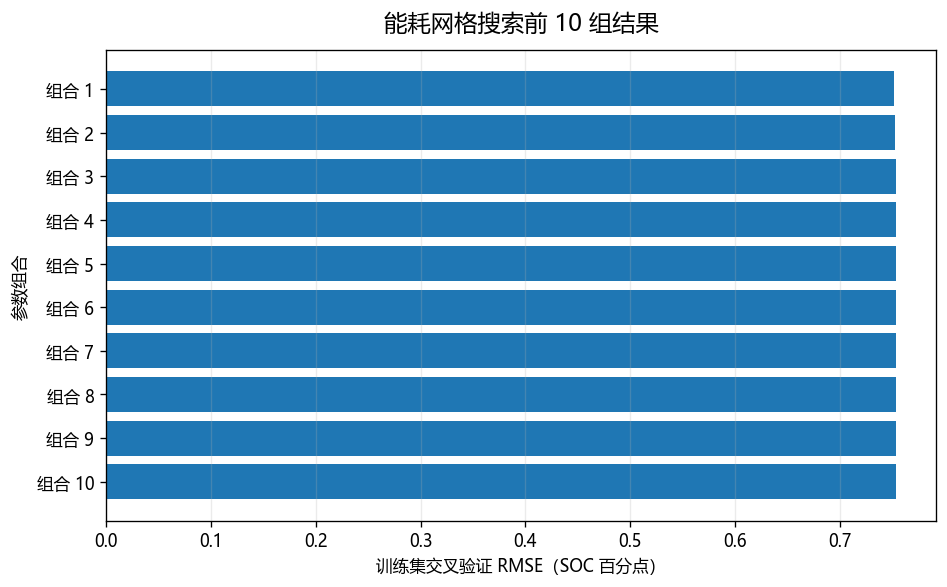

In [17]:
energy_grid_results = pd.DataFrame(
    energy_grid_search.cv_results_
)

energy_grid_results["CV_RMSE"] = (
    -energy_grid_results["mean_test_score"]
)

energy_grid_top10 = (
    energy_grid_results
    .sort_values("rank_test_score")
    .head(10)
    .copy()
)

energy_grid_top10["组合"] = [
    f"组合 {index}"
    for index in range(1, len(energy_grid_top10) + 1)
]

display(
    energy_grid_top10[
        ["组合", "CV_RMSE", "std_test_score", "params"]
    ].round(4)
)

plt.figure(figsize=(8, 5))
plt.barh(
    energy_grid_top10["组合"][::-1],
    energy_grid_top10["CV_RMSE"][::-1],
)
plt.xlabel("训练集交叉验证 RMSE（SOC 百分点）")
plt.ylabel("参数组合")
plt.title("能耗网格搜索前 10 组结果", fontsize=14, pad=12)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 9.6 使用两个最优 XGBoost 模型预测测试集

**本单元功能**

- 使用网格搜索得到的最佳时间模型和最佳能耗模型；
- 预测测试集；
- 计算最终测试集 MAE、RMSE 和 R²。

这里的 XGBoost 指标均来自网格搜索后的最优模型。

In [18]:
xgb_time_pred = xgb_time_model.predict(X_test)
xgb_energy_pred = xgb_energy_model.predict(X_test)

xgb_time_metrics = get_metrics(
    y_time_test,
    xgb_time_pred,
)

xgb_energy_metrics = get_metrics(
    y_energy_test,
    xgb_energy_pred,
)

print("网格搜索后的任务时间 XGBoost：")
display(pd.DataFrame(
    [xgb_time_metrics],
    index=["XGBoost（网格搜索）"],
).round(4))

print("网格搜索后的能耗 XGBoost：")
display(pd.DataFrame(
    [xgb_energy_metrics],
    index=["XGBoost（网格搜索）"],
).round(4))

网格搜索后的任务时间 XGBoost：


,MAE,RMSE,R2
XGBoost（网格搜索）,24.8802,36.3347,0.9651


网格搜索后的能耗 XGBoost：


,MAE,RMSE,R2
XGBoost（网格搜索）,0.5615,0.7309,0.9194


## 9.7 绘制最优 XGBoost 的预测结果

**本单元功能**

- 绘制时间模型的真实值—预测值图和残差图；
- 绘制能耗模型的真实值—预测值图和残差图。

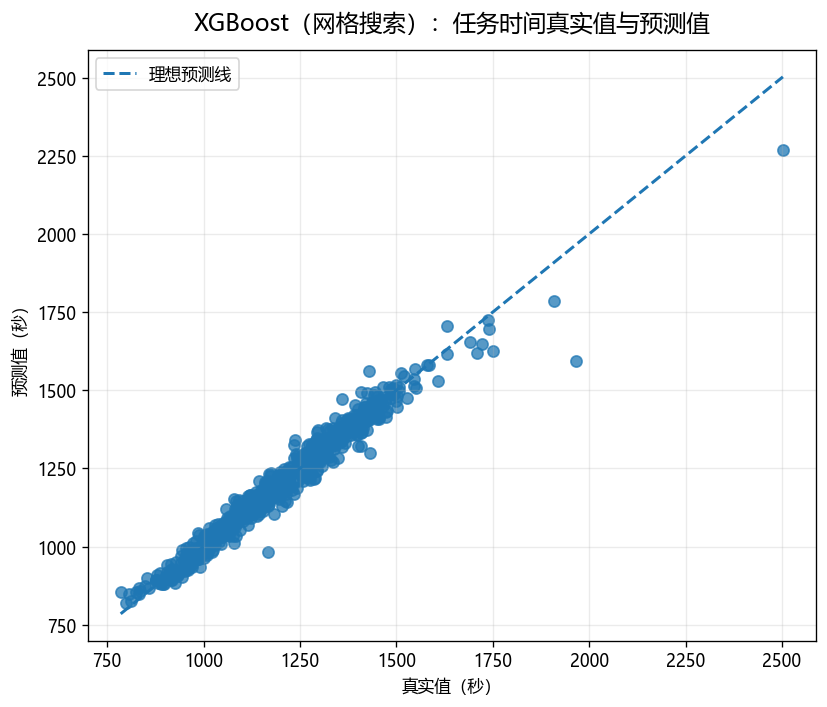

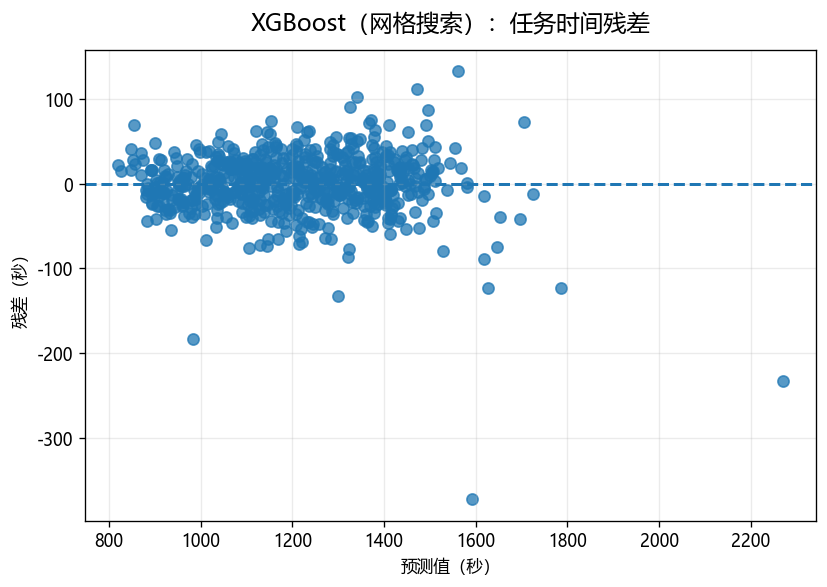

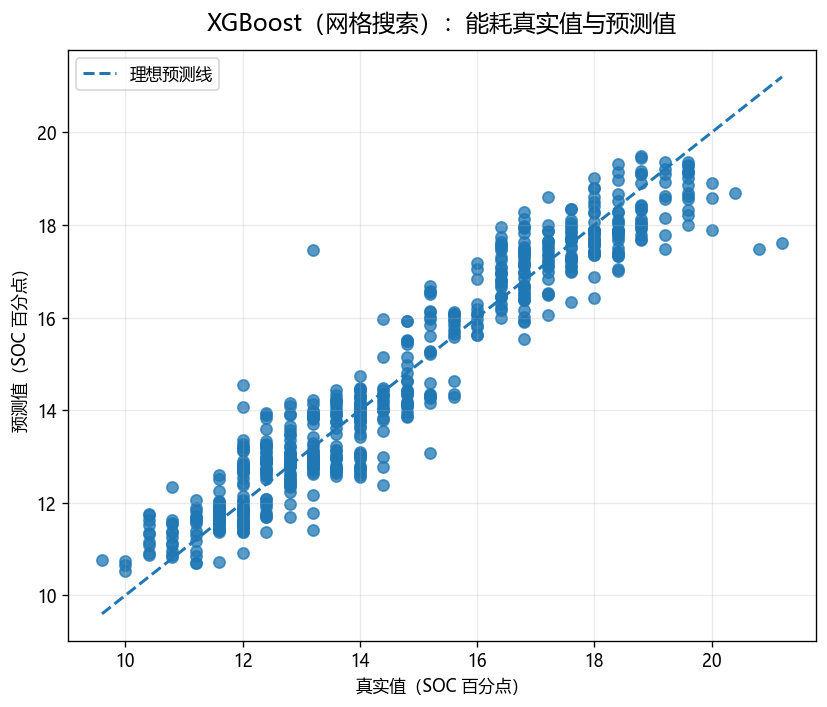

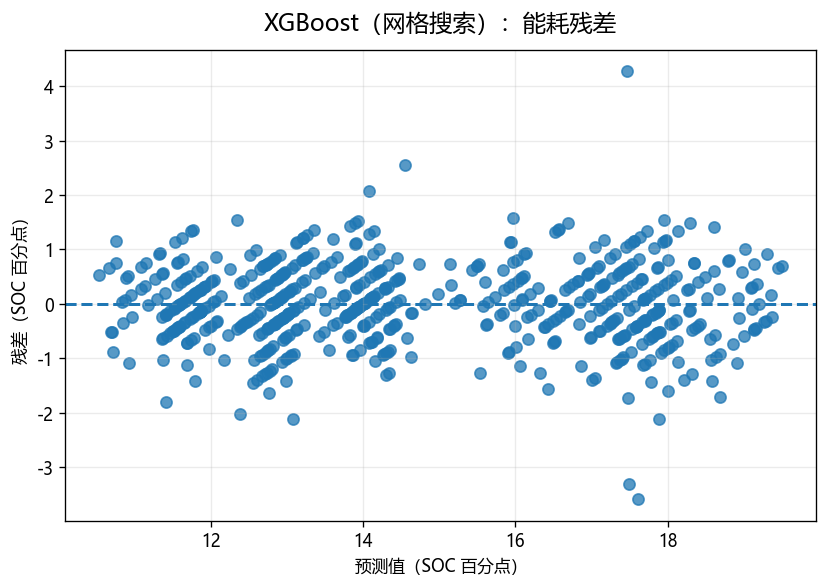

In [19]:
plot_actual_vs_predicted(
    y_time_test,
    xgb_time_pred,
    "XGBoost（网格搜索）：任务时间真实值与预测值",
    "秒",
)
plot_residuals(
    y_time_test,
    xgb_time_pred,
    "XGBoost（网格搜索）：任务时间残差",
    "秒",
)

plot_actual_vs_predicted(
    y_energy_test,
    xgb_energy_pred,
    "XGBoost（网格搜索）：能耗真实值与预测值",
    "SOC 百分点",
)
plot_residuals(
    y_energy_test,
    xgb_energy_pred,
    "XGBoost（网格搜索）：能耗残差",
    "SOC 百分点",
)

## 9.8 查看最优 XGBoost 的特征重要性

**本单元功能**

- 分别读取最终时间模型和能耗模型的特征重要性；
- 绘制横向条形图；
- 输出按重要性降序排列的表格。

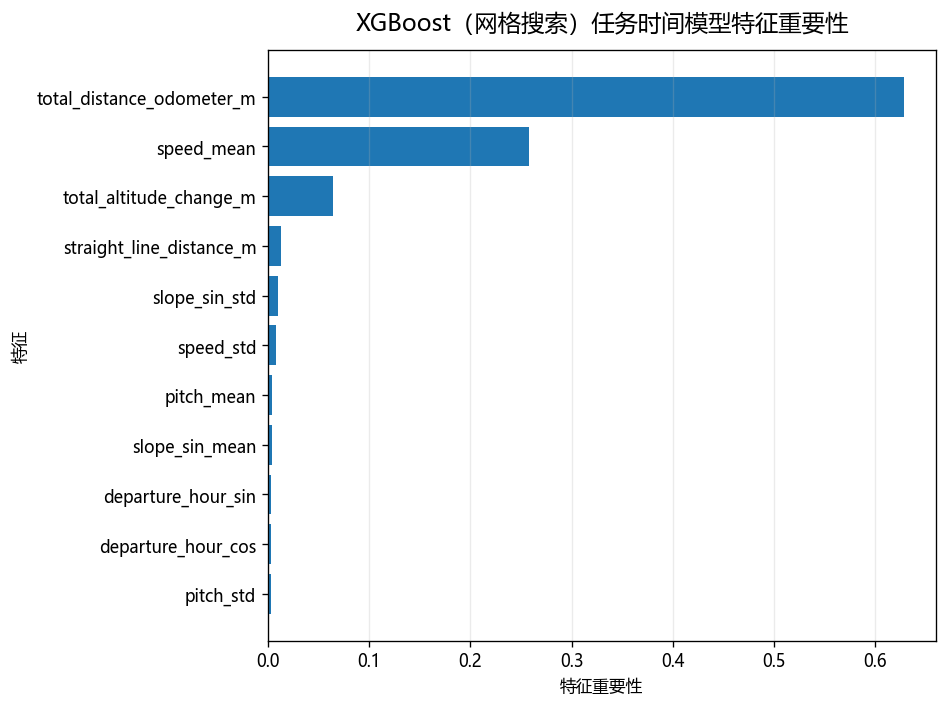

,feature,importance
2,total_distance_odometer_m,0.6287
6,speed_mean,0.2583
3,total_altitude_change_m,0.0644
10,straight_line_distance_m,0.0130
9,slope_sin_std,0.0101
7,speed_std,0.0084
4,pitch_mean,0.0041
8,slope_sin_mean,0.0039
0,departure_hour_sin,0.0033
1,departure_hour_cos,0.0029


In [20]:
time_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": xgb_time_model.feature_importances_,
}).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(
    time_importance["feature"],
    time_importance["importance"],
)
plt.xlabel("特征重要性")
plt.ylabel("特征")
plt.title(
    "XGBoost（网格搜索）任务时间模型特征重要性",
    fontsize=14,
    pad=12,
)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

display(
    time_importance
    .sort_values("importance", ascending=False)
    .round(4)
)

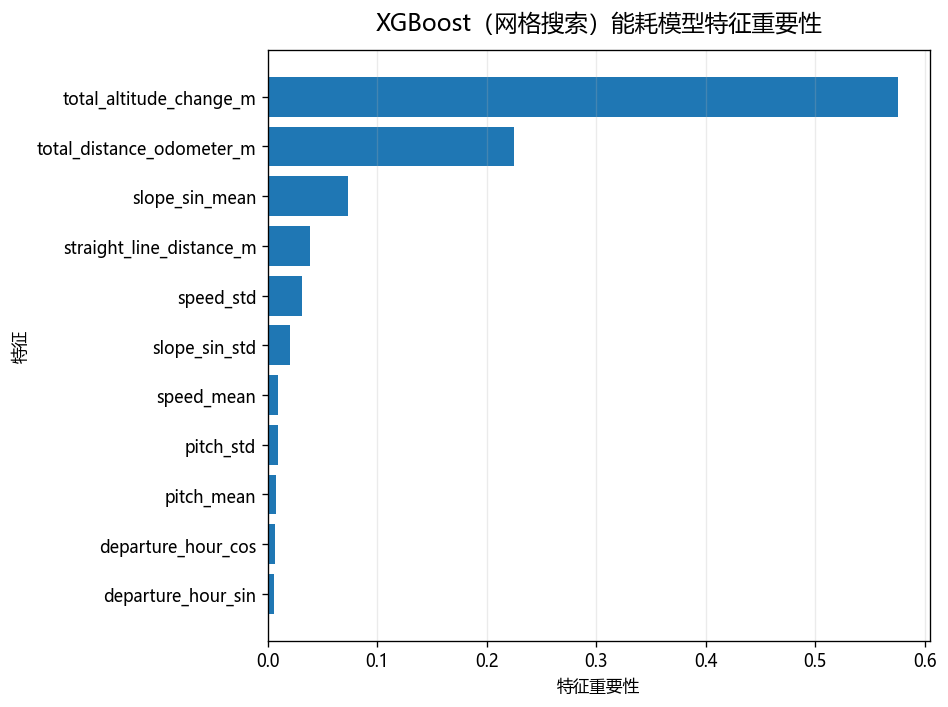

,feature,importance
3,total_altitude_change_m,0.5757
2,total_distance_odometer_m,0.2244
8,slope_sin_mean,0.0727
10,straight_line_distance_m,0.0385
7,speed_std,0.0315
9,slope_sin_std,0.0204
6,speed_mean,0.0090
5,pitch_std,0.0088
4,pitch_mean,0.0071
1,departure_hour_cos,0.0062


In [21]:
energy_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": xgb_energy_model.feature_importances_,
}).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(
    energy_importance["feature"],
    energy_importance["importance"],
)
plt.xlabel("特征重要性")
plt.ylabel("特征")
plt.title(
    "XGBoost（网格搜索）能耗模型特征重要性",
    fontsize=14,
    pad=12,
)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

display(
    energy_importance
    .sort_values("importance", ascending=False)
    .round(4)
)

# 10. 测试集模型统一比较

**本单元功能**

比较以下三类模型：

- 里程比例 Baseline；
- 线性回归；
- XGBoost（网格搜索）。

不再包含单独的默认参数 XGBoost。

In [22]:
time_comparison = pd.DataFrame([
    {
        "model": "里程比例 Baseline",
        **baseline1_time_metrics,
    },
    {
        "model": "线性回归",
        **linear_time_metrics,
    },
    {
        "model": "XGBoost（网格搜索）",
        **xgb_time_metrics,
    },
]).set_index("model")

energy_comparison = pd.DataFrame([
    {
        "model": "里程比例 Baseline",
        **baseline1_energy_metrics,
    },
    {
        "model": "线性回归",
        **linear_energy_metrics,
    },
    {
        "model": "XGBoost（网格搜索）",
        **xgb_energy_metrics,
    },
]).set_index("model")

print("任务时间测试集比较：")
display(time_comparison.round(4))

print("能耗测试集比较：")
display(energy_comparison.round(4))

任务时间测试集比较：


,MAE,RMSE,R2
model,,,
里程比例 Baseline,98.5729,137.0994,0.5025
线性回归,32.1469,45.1877,0.9460
XGBoost（网格搜索）,24.8802,36.3347,0.9651


能耗测试集比较：


,MAE,RMSE,R2
model,,,
里程比例 Baseline,1.4137,1.7477,0.5392
线性回归,0.6132,0.8012,0.9032
XGBoost（网格搜索）,0.5615,0.7309,0.9194


## 10.1 绘制测试集指标对比图

**本单元功能**

- 比较三个时间模型的 RMSE 和 R²；
- 比较三个能耗模型的 RMSE 和 R²。

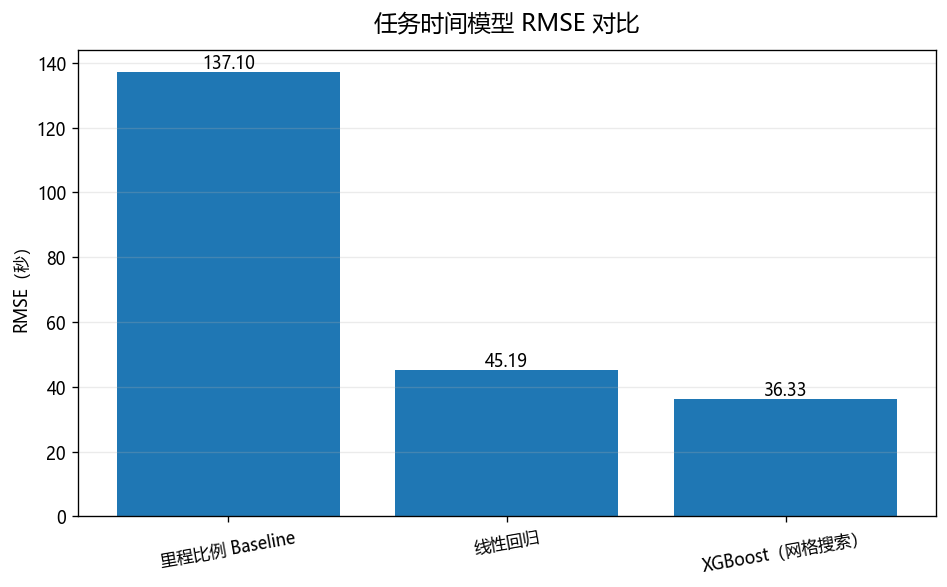

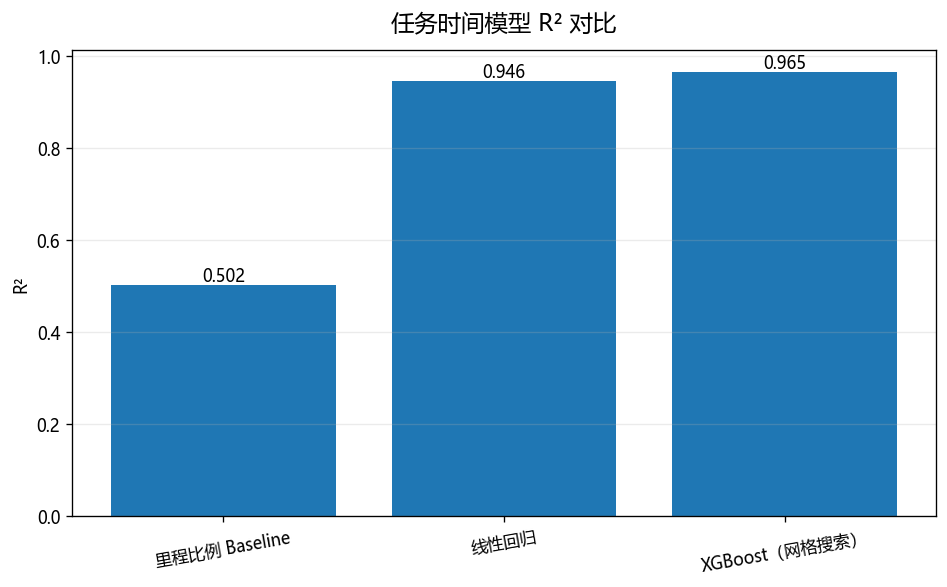

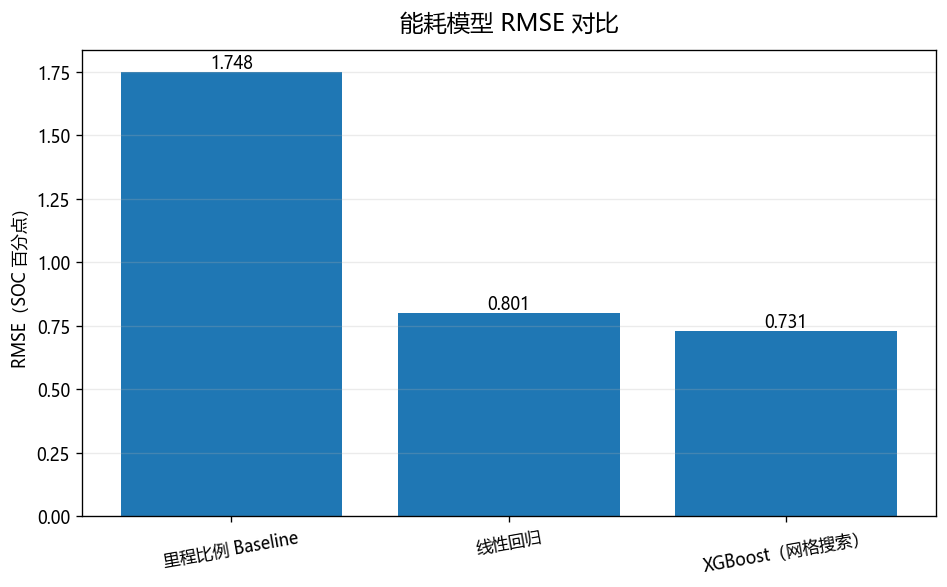

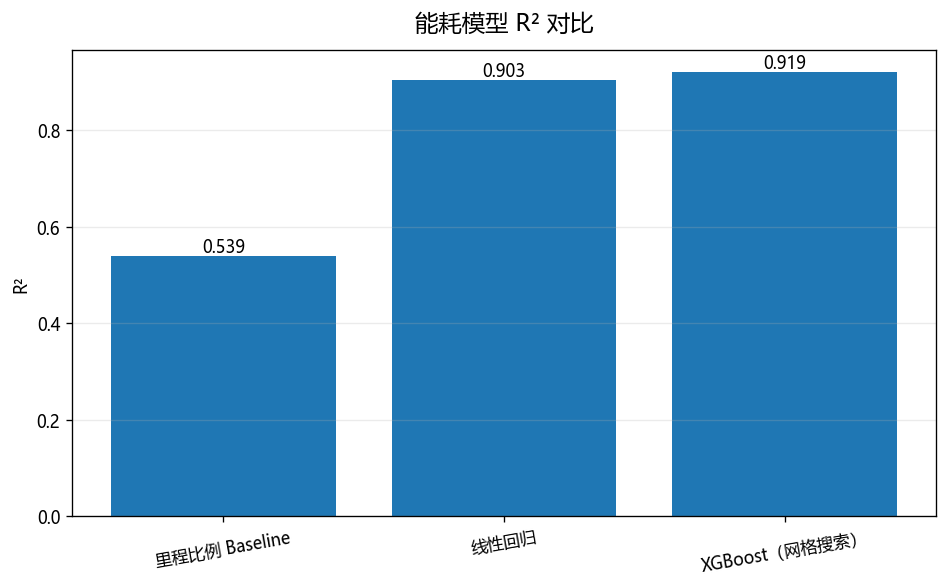

In [23]:
def plot_metric_comparison(
    comparison_df,
    metric,
    ylabel,
    title,
    decimal_places,
):
    plt.figure(figsize=(8, 5))
    bars = plt.bar(
        comparison_df.index,
        comparison_df[metric],
    )
    plt.ylabel(ylabel)
    plt.title(title, fontsize=14, pad=12)
    plt.grid(axis="y", alpha=0.25)

    for bar, value in zip(bars, comparison_df[metric]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.{decimal_places}f}",
            ha="center",
            va="bottom",
        )

    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()


plot_metric_comparison(
    time_comparison,
    metric="RMSE",
    ylabel="RMSE（秒）",
    title="任务时间模型 RMSE 对比",
    decimal_places=2,
)

plot_metric_comparison(
    time_comparison,
    metric="R2",
    ylabel="R²",
    title="任务时间模型 R² 对比",
    decimal_places=3,
)

plot_metric_comparison(
    energy_comparison,
    metric="RMSE",
    ylabel="RMSE（SOC 百分点）",
    title="能耗模型 RMSE 对比",
    decimal_places=3,
)

plot_metric_comparison(
    energy_comparison,
    metric="R2",
    ylabel="R²",
    title="能耗模型 R² 对比",
    decimal_places=3,
)

# 11. 可选：固定最优参数的 5 折稳定性检验

网格搜索已通过训练集交叉验证选择参数。本节是额外的模型稳定性比较，可按需要运行。

**说明**

- 里程比例模型每一折都重新计算比例系数；
- 线性回归每一折重新拟合；
- XGBoost 使用前面搜索出的最佳参数，每一折重新拟合；
- 这不是严格的嵌套交叉验证，因此不能代替独立测试集结果。

## 11.1 创建交叉验证器和评价指标

**本单元功能**

- 创建最多 5 折的随机 K 折；
- 定义 MAE、RMSE 和 R² 三个评分指标。

In [24]:
n_splits = min(5, len(df) // 2)

if n_splits < 2:
    raise ValueError("样本数太少，无法进行交叉验证。")

cv = KFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

print(f"使用 {n_splits} 折交叉验证。")

使用 5 折交叉验证。


## 11.2 计算里程比例 Baseline 的逐折结果

**本单元功能**

- 每一折只用该折训练数据计算时间和能耗比例系数；
- 在该折验证数据上计算指标；
- 保存每一折的系数和评价结果。

In [25]:
baseline1_cv_rows = []

for fold, (train_idx, valid_idx) in enumerate(
    cv.split(df),
    start=1,
):
    fold_train = df.iloc[train_idx]
    fold_valid = df.iloc[valid_idx]

    d_train = (
        fold_train["total_distance_odometer_m"]
        .to_numpy()
    )
    denominator = np.sum(d_train ** 2)

    if denominator == 0:
        raise ValueError(
            f"第 {fold} 折训练集里程全部为 0，"
            "无法拟合里程比例模型。"
        )

    t_train = fold_train[TIME_TARGET].to_numpy()
    e_train = fold_train[ENERGY_TARGET].to_numpy()

    fold_time_k = (
        np.sum(d_train * t_train)
        / denominator
    )
    fold_energy_k = (
        np.sum(d_train * e_train)
        / denominator
    )

    valid_distance = (
        fold_valid["total_distance_odometer_m"]
        .to_numpy()
    )

    fold_time_pred = fold_time_k * valid_distance
    fold_energy_pred = fold_energy_k * valid_distance

    fold_time_metrics = get_metrics(
        fold_valid[TIME_TARGET],
        fold_time_pred,
    )
    fold_energy_metrics = get_metrics(
        fold_valid[ENERGY_TARGET],
        fold_energy_pred,
    )

    baseline1_cv_rows.append({
        "fold": fold,
        "time_k_s_per_m": fold_time_k,
        "time_MAE": fold_time_metrics["MAE"],
        "time_RMSE": fold_time_metrics["RMSE"],
        "time_R2": fold_time_metrics["R2"],
        "energy_k_soc_pct_per_m": fold_energy_k,
        "energy_MAE": fold_energy_metrics["MAE"],
        "energy_RMSE": fold_energy_metrics["RMSE"],
        "energy_R2": fold_energy_metrics["R2"],
    })

baseline1_cv = pd.DataFrame(baseline1_cv_rows)
display(baseline1_cv.round(4))

,fold,time_k_s_per_m,time_MAE,time_RMSE,time_R2,energy_k_soc_pct_per_m,energy_MAE,energy_RMSE,energy_R2
0,1,0.3077,98.5729,137.0994,0.5025,0.0037,1.4137,1.7477,0.5392
1,2,0.3069,99.4823,149.9737,0.4176,0.0037,1.3779,1.6914,0.5481
2,3,0.3065,94.3225,145.1144,0.4768,0.0037,1.4452,1.7824,0.5225
3,4,0.3070,97.3593,139.9492,0.4849,0.0037,1.2797,1.5937,0.5945
4,5,0.3071,96.7458,137.1915,0.5178,0.0037,1.4088,1.7787,0.5620


## 11.3 计算线性回归和最优 XGBoost 的交叉验证结果

**本单元功能**

- 对线性回归执行交叉验证；
- 使用网格搜索得到的最佳参数构造 XGBoost；
- 分别评估任务时间和能耗预测稳定性；
- 不再计算默认参数 XGBoost。

In [26]:
linear_time_cv = cross_validate(
    LinearRegression(),
    df[FEATURE_COLS],
    df[TIME_TARGET],
    cv=cv,
    scoring=scoring,
)

linear_energy_cv = cross_validate(
    LinearRegression(),
    df[FEATURE_COLS],
    df[ENERGY_TARGET],
    cv=cv,
    scoring=scoring,
)

xgb_time_cv = cross_validate(
    XGBRegressor(
        objective="reg:squarederror",
        min_child_weight=2,
        reg_alpha=0.1,
        reg_lambda=3.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
        **time_grid_search.best_params_,
    ),
    df[FEATURE_COLS],
    df[TIME_TARGET],
    cv=cv,
    scoring=scoring,
)

xgb_energy_cv = cross_validate(
    XGBRegressor(
        objective="reg:squarederror",
        min_child_weight=2,
        reg_alpha=0.1,
        reg_lambda=3.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
        **energy_grid_search.best_params_,
    ),
    df[FEATURE_COLS],
    df[ENERGY_TARGET],
    cv=cv,
    scoring=scoring,
)

print("交叉验证完成。")

交叉验证完成。


## 11.4 汇总交叉验证平均指标

**本单元功能**

- 计算各模型跨折平均 MAE、RMSE 和 R²；
- 分别生成时间预测和能耗预测的稳定性对比表。

In [27]:
time_cv_comparison = pd.DataFrame([
    {
        "model": "里程比例 Baseline",
        "CV_MAE": baseline1_cv["time_MAE"].mean(),
        "CV_RMSE": baseline1_cv["time_RMSE"].mean(),
        "CV_R2": baseline1_cv["time_R2"].mean(),
    },
    {
        "model": "线性回归",
        "CV_MAE": -linear_time_cv["test_MAE"].mean(),
        "CV_RMSE": -linear_time_cv["test_RMSE"].mean(),
        "CV_R2": linear_time_cv["test_R2"].mean(),
    },
    {
        "model": "XGBoost（网格搜索）",
        "CV_MAE": -xgb_time_cv["test_MAE"].mean(),
        "CV_RMSE": -xgb_time_cv["test_RMSE"].mean(),
        "CV_R2": xgb_time_cv["test_R2"].mean(),
    },
]).set_index("model")

energy_cv_comparison = pd.DataFrame([
    {
        "model": "里程比例 Baseline",
        "CV_MAE": baseline1_cv["energy_MAE"].mean(),
        "CV_RMSE": baseline1_cv["energy_RMSE"].mean(),
        "CV_R2": baseline1_cv["energy_R2"].mean(),
    },
    {
        "model": "线性回归",
        "CV_MAE": -linear_energy_cv["test_MAE"].mean(),
        "CV_RMSE": -linear_energy_cv["test_RMSE"].mean(),
        "CV_R2": linear_energy_cv["test_R2"].mean(),
    },
    {
        "model": "XGBoost（网格搜索）",
        "CV_MAE": -xgb_energy_cv["test_MAE"].mean(),
        "CV_RMSE": -xgb_energy_cv["test_RMSE"].mean(),
        "CV_R2": xgb_energy_cv["test_R2"].mean(),
    },
]).set_index("model")

print("任务时间交叉验证平均结果：")
display(time_cv_comparison.round(4))

print("能耗交叉验证平均结果：")
display(energy_cv_comparison.round(4))

任务时间交叉验证平均结果：


,CV_MAE,CV_RMSE,CV_R2
model,,,
里程比例 Baseline,97.2966,141.8656,0.4799
线性回归,33.1065,46.8341,0.9433
XGBoost（网格搜索）,24.4130,34.0882,0.9698


能耗交叉验证平均结果：


,CV_MAE,CV_RMSE,CV_R2
model,,,
里程比例 Baseline,1.3851,1.7188,0.5533
线性回归,0.6052,0.7958,0.9042
XGBoost（网格搜索）,0.5752,0.7447,0.9162


## 11.5 绘制交叉验证 R² 对比图

**本单元功能**

- 绘制时间模型平均交叉验证 R²；
- 绘制能耗模型平均交叉验证 R²。

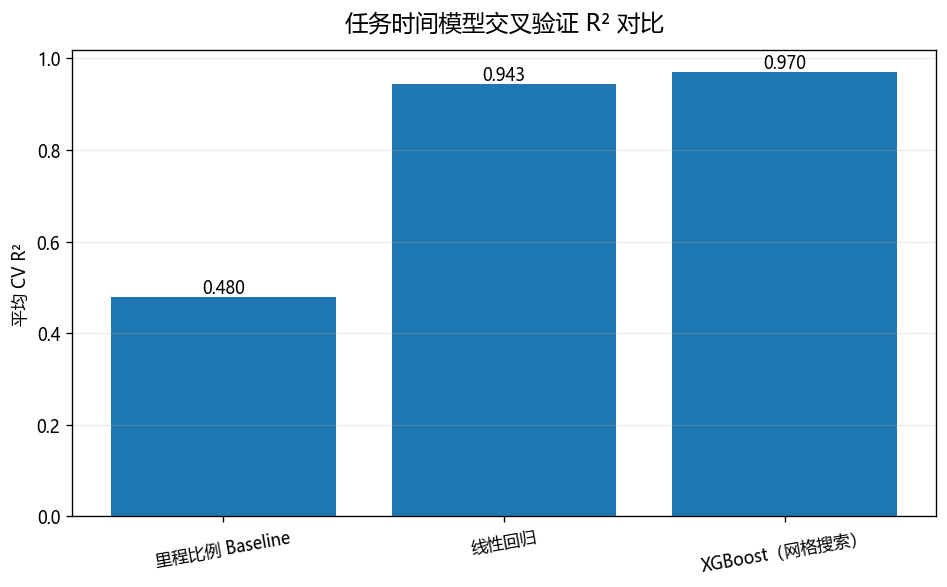

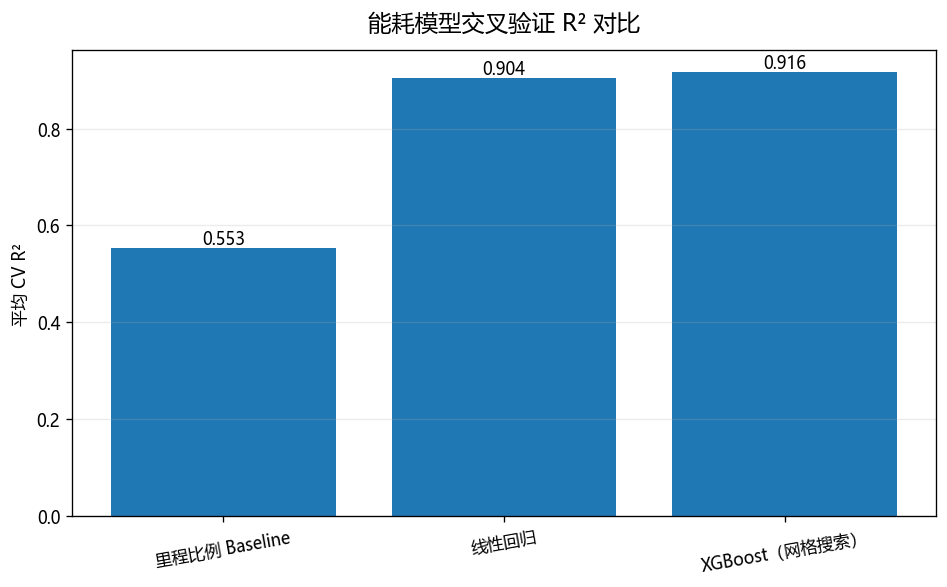

In [28]:
plot_metric_comparison(
    time_cv_comparison,
    metric="CV_R2",
    ylabel="平均 CV R²",
    title="任务时间模型交叉验证 R² 对比",
    decimal_places=3,
)

plot_metric_comparison(
    energy_cv_comparison,
    metric="CV_R2",
    ylabel="平均 CV R²",
    title="能耗模型交叉验证 R² 对比",
    decimal_places=3,
)

# 12. 保存模型、参数、搜索结果和预测结果

**本单元功能**

保存以下内容：

- 里程比例 Baseline 系数；
- 两个线性回归模型；
- 两个网格搜索后的最优 XGBoost 模型；
- XGBoost 最优参数；
- 完整网格搜索结果；
- 测试集逐条预测；
- 测试集和交叉验证指标。

不再保存默认参数 XGBoost 模型或默认参数预测列。

In [29]:
# 1. 保存里程比例模型
baseline1_model_path = (
    OUTPUT_DIR
    / "baseline1_distance_time_energy_model.json"
)

with baseline1_model_path.open("w", encoding="utf-8") as file:
    json.dump(
        baseline1_model_data,
        file,
        ensure_ascii=False,
        indent=2,
    )


# 2. 保存线性回归模型
joblib.dump(
    linear_time_model,
    OUTPUT_DIR / "linear_time_model.joblib",
)
joblib.dump(
    linear_energy_model,
    OUTPUT_DIR / "linear_energy_model.joblib",
)


# 3. 保存网格搜索后的最优 XGBoost 模型
joblib.dump(
    xgb_time_model,
    OUTPUT_DIR / "xgboost_time_grid_search_model.joblib",
)
joblib.dump(
    xgb_energy_model,
    OUTPUT_DIR / "xgboost_energy_grid_search_model.joblib",
)


# 4. 保存网格搜索最优参数
best_grid_parameters = {
    "time_best_params": time_grid_search.best_params_,
    "time_best_cv_rmse": -time_grid_search.best_score_,
    "energy_best_params": energy_grid_search.best_params_,
    "energy_best_cv_rmse": -energy_grid_search.best_score_,
}

with (
    OUTPUT_DIR / "xgboost_grid_search_best_parameters.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        best_grid_parameters,
        file,
        ensure_ascii=False,
        indent=2,
    )


# 5. 保存完整网格搜索结果
time_grid_results.to_csv(
    OUTPUT_DIR / "time_grid_search_results.csv",
    index=False,
    encoding="utf-8-sig",
)

energy_grid_results.to_csv(
    OUTPUT_DIR / "energy_grid_search_results.csv",
    index=False,
    encoding="utf-8-sig",
)


# 6. 保存测试集逐条预测
prediction_result = test_df[
    [
        "task_id",
        "task_index",
        "source_file",
        "total_distance_odometer_m",
        TIME_TARGET,
        ENERGY_TARGET,
    ]
].copy()

prediction_result["baseline1_time_pred_s"] = baseline1_time_pred
prediction_result["baseline1_energy_pred_pct"] = baseline1_energy_pred
prediction_result["linear_time_pred_s"] = linear_time_pred
prediction_result["linear_energy_pred_pct"] = linear_energy_pred
prediction_result["xgboost_time_grid_pred_s"] = xgb_time_pred
prediction_result["xgboost_energy_grid_pred_pct"] = xgb_energy_pred

prediction_result.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)


# 7. 保存评价指标
time_comparison.to_csv(
    OUTPUT_DIR / "time_test_metrics.csv",
    encoding="utf-8-sig",
)

energy_comparison.to_csv(
    OUTPUT_DIR / "energy_test_metrics.csv",
    encoding="utf-8-sig",
)

# 仅当已运行第 11 节时，保存交叉验证指标
if "time_cv_comparison" in globals():
    time_cv_comparison.to_csv(
        OUTPUT_DIR / "time_cross_validation_metrics.csv",
        encoding="utf-8-sig",
    )

if "energy_cv_comparison" in globals():
    energy_cv_comparison.to_csv(
        OUTPUT_DIR / "energy_cross_validation_metrics.csv",
        encoding="utf-8-sig",
    )

print("全部结果已保存到：", OUTPUT_DIR)
display(prediction_result.head(10).round(4))

全部结果已保存到： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\ModelResults


,task_id,task_index,source_file,total_distance_odometer_m,task_duration_s,total_energy_soc_delta_pct,baseline1_time_pred_s,baseline1_energy_pred_pct,linear_time_pred_s,linear_energy_pred_pct,xgboost_time_grid_pred_s,xgboost_energy_grid_pred_pct
0,8065986810708225,51,TLE00860HR1450010卸料任务_特征和标签.json,3375.0,1002.1024,14.4,1038.3783,12.5795,1042.6817,14.1067,1023.068298,13.831200
1,8066176061194497,57,TLE00900CR1450050卸料任务_特征和标签.json,4375.0,1409.4458,18.4,1346.0459,16.3067,1376.1965,17.1633,1385.912720,17.892799
2,8094951438336257,101,TLE00900VR1450048最终有效卸货记录615-707_cleaned_特征和标签...,3250.0,1025.8506,13.2,999.9198,12.1136,1070.7872,11.4144,1020.380310,11.406600
3,8062584127078657,14,TLE00900JR1450046卸料任务_特征和标签.json,3250.0,1140.1710,13.6,999.9198,12.1136,1100.2404,13.7680,1135.596313,13.740800
4,8099212179472641,143,TLE00860VR1450018最终有效卸货记录615-707_cleaned_特征和标签...,3500.0,1194.9745,12.0,1076.8368,13.0454,1279.0431,11.9360,1226.829590,11.850200
5,8066256954654977,57,TLE00900AR1450052卸料任务_特征和标签.json,5250.0,1426.3102,18.0,1615.2551,19.5681,1407.9727,16.9514,1433.933350,17.347799
6,8087961773113601,34,TLE00860HR1450010最终有效卸货记录615-707_cleaned_特征和标签...,4125.0,1113.0407,12.8,1269.1290,15.3749,1055.5481,12.9744,1090.851562,12.949900
7,8101046186524929,184,TLE00900CR1450050最终有效卸货记录615-707_cleaned_特征和标签...,3125.0,1303.7853,12.8,961.4614,11.6477,1305.0034,13.0494,1318.717285,13.068900
8,8065180703752449,41,TLE00860HR1450010卸料任务_特征和标签.json,3875.0,1203.6099,16.8,1192.2121,14.4431,1237.8313,16.1503,1184.701416,16.386000
9,8085294128709889,7,TLE00900AR1450049最终有效卸货记录615-707_cleaned_特征和标签...,4375.0,1291.9774,17.6,1346.0459,16.3067,1302.4970,17.5049,1314.647217,17.712400


# 13. 结果阅读顺序

建议按以下顺序检查结果：

1. 查看两个 XGBoost 网格搜索单元输出的最优参数和训练集 CV RMSE；
2. 查看测试集统一比较表中的 RMSE 和 R²；
3. 检查真实值—预测值图是否接近对角线；
4. 检查残差是否围绕 0 随机分布；
5. 查看最优 XGBoost 的特征重要性；
6. 根据需要运行第 11 节，检查固定最优参数下的跨折稳定性。

注意：

- 测试集不能用于选择参数；
- 网格搜索只能找到当前候选范围内的最优组合；
- 可以围绕第一轮最优参数设置更细的第二轮网格；
- 如果目标是发车前预测，应检查 `speed_mean`、`speed_std` 等全程统计特征是否造成信息泄漏。